
<a id="summary"></a>

## Notebook 3 — RFM scoring & clustering (behavioral segments)

**v1.** This notebook engineers **RFM features** at **customer** grain (on top of completed transactions), prepares **clustering** on behavioral patterns, and targets roadmap **Q6–Q10** from `docs/fintech-ai-segmentation-summary.md`.

### How this notebook is organized

**Jump to parts:** 

1. [Part 1 — RFM design & data loading](#part-1)
2. [Part 2 — RFM metrics and Feature Engineering]((#part-2))
3. [Part 3 — clustering & segment profiles]((#part-3))
4. [Part 4 — products & utilization]((#part-4))

**Part 1 — RFM design & data loading**

1.1 [RFM ranking criteria (locked definitions)](#rfm-criteria)
1.2 [Load raw tables from Supabase](#q1)
1.3 [Join transactions to customer attributes](#q2)
1.4 [Transaction month buckets & incomplete last month](#q3)

---

### Objectives

- **This pass:** Document **RFM criteria**, import libraries, load **`customers_raw`**, **`transactions_raw`**, **`products_raw`**, **`customer_products_raw`**, build **`df_tx`** with the same **incomplete trailing month** rule as notebook 2, and pin **`as_of_date`**. **F** and **M** use the **full retained history** (no extra 12-month cap).
- **Later:** Quintile scores, K-Means / segments, answers to Q6–Q10 (including product counts and credit utilization when features exist).

### Business questions (Behavioral Intelligence)

6. Who are our most valuable customers right now?
7. What behavioral patterns define each customer segment?
8. What is the RFM profile of each segment?
9. Do high-engagement customers own more products?
10. How does credit utilization vary across segments? *(requires engineered `customers_features` or a documented proxy — see [RFM criteria](#rfm-criteria).)*

### Expected output

- **`df_tx`**: completed transactions joined to customers, **after** dropping an incomplete latest calendar month when applicable.
- **`as_of_date`**: reference instant for **recency**; **frequency** and **monetary** are computed over **all** completed transactions in `df_tx` with `transaction_datetime` ≤ `as_of_date` (full observation window—e.g. multi-year history—minus only the incomplete last month when dropped).
- **`df_products`**, **`df_customer_products`**: for product-ownership analysis (Q9).
- Later: per-customer **`recency_days`**, **`frequency`** (count), **`monetary`** (sum), quintile scores, **`rfm_score`**, **`predicted_segment`**.



<a id="rfm-criteria"></a>

### RFM ranking criteria (v1)

These definitions stay aligned with [`2.EDA_cohort_analysis.ipynb`](2.EDA_cohort_analysis.ipynb) calendar rules and with [`docs/notebooks-roadmap.md`](docs/notebooks-roadmap.md) Notebook 4.

**Observation window:** Use **all** completed transactions that remain in **`df_tx`** after filters. The only calendar cut is dropping the **latest month** when it is **incomplete** (rule below). 

| Topic | Rule |
|-------|------|
| **Calendar completeness** | Before computing RFM, drop the **latest calendar month** in `transaction_datetime` if coverage is incomplete: require at least **`min(20, days_in_month)`** distinct calendar days with at least one **completed** transaction in that month. Recompute `transaction_month` / `registration_month` after the drop. |
| **`as_of_date`** | **`max(transaction_datetime)`** on the retained **`df_tx`** rows (after the incomplete-month drop). End of usable snapshot—typically aligned with the **last complete calendar month** when the latest month was removed. |
| **Recency (R)** | Days from **`as_of_date`** to each customer's **last** completed transaction timestamp (`>= 0`). Customers with no transaction in the retained data are out of scope for RFM until handled explicitly. |
| **Frequency (F)** | Count of completed transactions per customer with `transaction_datetime` **≤ `as_of_date`**, over the **full retained window** (all history in `df_tx` after filters—not limited to 12 months). Optionally exclude **`transaction_type = 'refund'`** from the count. |
| **Monetary (M)** | Sum of **`amount`** over the **same rows as F**. Exclude **`transaction_type = 'refund'`** from F and M when that column is present (or net, if you define a refund rule). |
| **Scores 1–5** | **Quintiles** on each dimension among eligible customers: higher score = more recent (lower days), higher frequency, higher monetary. Ties: use `method='first'` in `pandas.qcut` unless we document otherwise. |
| **Combined `rfm_score`** | For ordering: **`100 * R_score + 10 * F_score + M_score`** (so lexicographic R → F → M). For reporting, also keep the three scores separate. |


[↑ Back to summary](#summary)


In [1]:

# ── Importing libraries ──────────────────────────────────────────────────────

import os

import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter

from IPython.display import display

sns.set_theme(style="whitegrid")


def format_brl_value(value):
    formatted = f"{value:,.2f}".replace(",", "_").replace(".", ",").replace("_", ".")
    return f"R$ {formatted}"


def format_brl(value, pos):
    return format_brl_value(value)



<a id="part-1"></a>

## Part 1 — RFM design & data loading

**Goal:** pull raw tables from Supabase, build **`df_tx`** (completed transactions + customer attributes), apply the **incomplete latest month** rule from notebook 2, and set **`as_of_date`**.

[↑ Back to summary](#summary)



<a id="q1"></a>

### 1. Load `customers_raw`, `transactions_raw`, `products_raw`, `customer_products_raw` from Supabase

[↑ Back to summary](#summary)


In [2]:

# override=True ensures .env changes are picked up without restarting the kernel
load_dotenv(override=True)

DATABASE_URL = os.environ["SUPABASE_DATABASE_URL"]

engine = create_engine(
    DATABASE_URL,
    pool_pre_ping=True,  # helps avoid stale connections in notebooks
)

sql_customers = text(
    "SELECT\n"
    "  customer_id,\n"
    "  acquisition_channel,\n"
    "  acquisition_cost,\n"
    "  registration_date,\n"
    "  true_segment\n"
    "FROM public.customers_raw\n"
)

df_customers = pd.read_sql(sql_customers, engine)

sql_transactions = text(
    "SELECT\n"
    "  transaction_id,\n"
    "  customer_id,\n"
    "  transaction_datetime,\n"
    "  amount,\n"
    "  transaction_type,\n"
    "  product_type,\n"
    "  channel,\n"
    "  status\n"
    "FROM public.transactions_raw\n"
    "WHERE status = 'completed'\n"
)

df_transactions = pd.read_sql(sql_transactions, engine)

sql_products = text(
    "SELECT\n"
    "  product_id,\n"
    "  product_name,\n"
    "  product_type\n"
    "FROM public.products_raw\n"
)

df_products = pd.read_sql(sql_products, engine)

sql_customer_products = text(
    "SELECT\n"
    "  customer_id,\n"
    "  product_id,\n"
    "  start_date,\n"
    "  is_active\n"
    "FROM public.customer_products_raw\n"
)

df_customer_products = pd.read_sql(sql_customer_products, engine)



In [3]:
print("df_customers:", df_customers.shape)
display(df_customers.head())


df_customers: (8000, 5)


,customer_id,acquisition_channel,acquisition_cost,registration_date,true_segment
0,460cf2eb-14a8-4373-8116-1a1aa1ae4a39,partnership,132.04,2026-01-30 00:00:00+00:00,high_value_active
1,60f6e3c6-3743-440b-bcdd-ff1603f78f95,organic,12.61,2025-12-22 00:00:00+00:00,high_value_active
2,fb711018-ccba-47a2-9266-0136669adcb3,referral,63.92,2024-12-02 00:00:00+00:00,high_value_active
3,14c32f3e-420c-4076-95ec-5fb103b9c59d,partnership,106.18,2024-04-28 00:00:00+00:00,high_value_active
4,94c8d245-fe90-45dc-874a-c3c0bfa9b873,partnership,116.35,2026-01-16 00:00:00+00:00,high_value_active


In [4]:
print("df_transactions (completed):", df_transactions.shape)
display(df_transactions.head())


df_transactions (completed): (1196165, 8)


,transaction_id,customer_id,transaction_datetime,amount,transaction_type,product_type,channel,status
0,9c8cb66d-44b7-44bf-8709-d4f69918772d,d32c3df8-036e-4b25-b43e-d6622104e5b7,2025-07-27 09:50:40.525931+00:00,304.98,purchase,credit_card,card_present,completed
1,39cf0f7a-61c2-4cca-bd38-4795284bc754,d32c3df8-036e-4b25-b43e-d6622104e5b7,2026-02-24 10:31:25.548874+00:00,274.10,fee,wallet,in_app,completed
2,98fca44e-ac92-4d36-ab9e-55680f4dafcc,d32c3df8-036e-4b25-b43e-d6622104e5b7,2025-07-01 10:00:06.013861+00:00,218.69,cash_withdrawal,wallet,atm,completed
3,f755eeb3-4884-4a72-a1f4-8c610c4e016e,d32c3df8-036e-4b25-b43e-d6622104e5b7,2025-09-26 18:16:41.153502+00:00,396.11,transfer,wallet,in_app,completed
4,d113cdcf-d107-4ac6-b4af-5495600ef07f,d32c3df8-036e-4b25-b43e-d6622104e5b7,2025-02-19 07:49:20.163390+00:00,5.00,cash_withdrawal,wallet,in_app,completed


In [5]:
print("df_products:", df_products.shape)
display(df_products.head())


df_products: (5, 3)


,product_id,product_name,product_type
0,02426d29-8271-44a0-91ca-62ba803ade16,Digital Wallet,wallet
1,3a794adb-39f6-4396-8bda-c5b696187aac,SynaptiqPay Credit Card,credit_card
2,85516d92-f18e-4073-a8e9-31f192e381f8,Investment Account,investment
3,5caaa31e-7ff2-48e2-b4ec-7686be3e04df,Device Insurance,insurance
4,6b6b03a3-90bc-426d-ad06-907b0994bd76,Personal Loan,loan


In [6]:
print("df_customer_products:", df_customer_products.shape)
display(df_customer_products.head())


df_customer_products: (19659, 4)


,customer_id,product_id,start_date,is_active
0,460cf2eb-14a8-4373-8116-1a1aa1ae4a39,02426d29-8271-44a0-91ca-62ba803ade16,2026-02-12 00:00:00+00:00,True
1,60f6e3c6-3743-440b-bcdd-ff1603f78f95,02426d29-8271-44a0-91ca-62ba803ade16,2026-02-20 00:00:00+00:00,True
2,60f6e3c6-3743-440b-bcdd-ff1603f78f95,3a794adb-39f6-4396-8bda-c5b696187aac,2026-02-18 00:00:00+00:00,True
3,60f6e3c6-3743-440b-bcdd-ff1603f78f95,85516d92-f18e-4073-a8e9-31f192e381f8,2026-02-17 00:00:00+00:00,False
4,60f6e3c6-3743-440b-bcdd-ff1603f78f95,5caaa31e-7ff2-48e2-b4ec-7686be3e04df,2026-02-13 00:00:00+00:00,False



<a id="q2"></a>

### 2. Join transactions to customer attributes

`df_transactions` is merged with `df_customers` on **`customer_id`** (inner join) so every row carries **`acquisition_channel`**, **`true_segment`**, and **`registration_date`**.

[↑ Back to summary](#summary)


In [7]:
# Join transactions to customer attributes
df_tx = df_transactions.merge(df_customers, on="customer_id", how="inner")



<a id="q3"></a>

### 3. Transaction month buckets & incomplete latest month

We normalize **`transaction_datetime`** and **`registration_date`** to month-start timestamps, ensure **`amount`** is numeric, then **drop the trailing calendar month** when intra-month coverage is below the same threshold as [`2.EDA_cohort_analysis.ipynb`](2.EDA_cohort_analysis.ipynb) (**`min(20, days_in_month)`** distinct days with activity).

After that, **`as_of_date`** is the maximum **`transaction_datetime`** on retained rows.

[↑ Back to summary](#summary)


In [8]:

# Transaction month (calendar month start)
tx_dt = df_tx["transaction_datetime"]
if isinstance(tx_dt.dtype, pd.DatetimeTZDtype):
    tx_dt = tx_dt.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["transaction_month"] = tx_dt.dt.to_period("M").dt.to_timestamp()

# Registration month (cohort month anchor)
reg = df_tx["registration_date"]
if isinstance(reg.dtype, pd.DatetimeTZDtype):
    reg = reg.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["registration_month"] = reg.dt.to_period("M").dt.to_timestamp()

# Amount numeric
df_tx["amount"] = pd.to_numeric(df_tx["amount"], errors="coerce")

# Drop the trailing calendar month if we don't yet have enough intra-month coverage.
# Rule: keep the latest month only if `transaction_datetime` includes activity on
# at least 20 distinct calendar days within that month (days 1–20+).
MIN_DISTINCT_DAYS_IN_LATEST_MONTH = 20

_tx_dt_guard = df_tx["transaction_datetime"]
if isinstance(_tx_dt_guard.dtype, pd.DatetimeTZDtype):
    _tx_dt_guard = _tx_dt_guard.dt.tz_convert("UTC").dt.tz_localize(None)

last_month_period = _tx_dt_guard.dt.to_period("M").max()
last_month_mask = _tx_dt_guard.dt.to_period("M") == last_month_period

distinct_days = _tx_dt_guard.loc[last_month_mask].dt.day.nunique()

days_in_month = last_month_period.days_in_month if pd.notna(last_month_period) else None
threshold = min(MIN_DISTINCT_DAYS_IN_LATEST_MONTH, days_in_month) if days_in_month is not None else MIN_DISTINCT_DAYS_IN_LATEST_MONTH

if pd.notna(last_month_period) and distinct_days < threshold:
    print(
        f"Dropping latest month {last_month_period} from df_tx: "
        f"only {distinct_days} distinct day(s) observed (threshold={threshold} of {days_in_month} days in month)."
    )
    df_tx = df_tx.loc[~last_month_mask].copy()
else:
    print(
        f"Keeping latest month {last_month_period}: "
        f"{distinct_days} distinct day(s) observed (threshold={threshold} of {days_in_month} days in month)."
    )

# Keep derived month columns consistent after potential row drops
_tx_dt2 = df_tx["transaction_datetime"]
if isinstance(_tx_dt2.dtype, pd.DatetimeTZDtype):
    _tx_dt2 = _tx_dt2.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["transaction_month"] = _tx_dt2.dt.to_period("M").dt.to_timestamp()

_reg2 = df_tx["registration_date"]
if isinstance(_reg2.dtype, pd.DatetimeTZDtype):
    _reg2 = _reg2.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["registration_month"] = _reg2.dt.to_period("M").dt.to_timestamp()

print("df_tx (joined):", df_tx.shape)
display(df_tx.head())

# Latest complete calendar month observed in completed transactions
latest_complete_month = df_tx["transaction_month"].max().to_period("M")
print("latest_complete_month:", latest_complete_month)

# Reference instant for RFM (recency anchor; F/M use full retained history up to here)
as_of_date = df_tx["transaction_datetime"].max()
print("as_of_date:", as_of_date)


Dropping latest month 2026-03 from df_tx: only 1 distinct day(s) observed (threshold=20 of 31 days in month).
df_tx (joined): (1136270, 14)


,transaction_id,customer_id,transaction_datetime,amount,transaction_type,product_type,channel,status,acquisition_channel,acquisition_cost,registration_date,true_segment,transaction_month,registration_month
0,9c8cb66d-44b7-44bf-8709-d4f69918772d,d32c3df8-036e-4b25-b43e-d6622104e5b7,2025-07-27 09:50:40.525931+00:00,304.98,purchase,credit_card,card_present,completed,referral,49.51,2024-04-09 00:00:00+00:00,high_value_active,2025-07-01,2024-04-01
1,39cf0f7a-61c2-4cca-bd38-4795284bc754,d32c3df8-036e-4b25-b43e-d6622104e5b7,2026-02-24 10:31:25.548874+00:00,274.10,fee,wallet,in_app,completed,referral,49.51,2024-04-09 00:00:00+00:00,high_value_active,2026-02-01,2024-04-01
2,98fca44e-ac92-4d36-ab9e-55680f4dafcc,d32c3df8-036e-4b25-b43e-d6622104e5b7,2025-07-01 10:00:06.013861+00:00,218.69,cash_withdrawal,wallet,atm,completed,referral,49.51,2024-04-09 00:00:00+00:00,high_value_active,2025-07-01,2024-04-01
3,f755eeb3-4884-4a72-a1f4-8c610c4e016e,d32c3df8-036e-4b25-b43e-d6622104e5b7,2025-09-26 18:16:41.153502+00:00,396.11,transfer,wallet,in_app,completed,referral,49.51,2024-04-09 00:00:00+00:00,high_value_active,2025-09-01,2024-04-01
4,d113cdcf-d107-4ac6-b4af-5495600ef07f,d32c3df8-036e-4b25-b43e-d6622104e5b7,2025-02-19 07:49:20.163390+00:00,5.00,cash_withdrawal,wallet,in_app,completed,referral,49.51,2024-04-09 00:00:00+00:00,high_value_active,2025-02-01,2024-04-01


latest_complete_month: 2026-02
as_of_date: 2026-02-28 23:59:15.547645+00:00


/var/folders/sc/vkhmk96s2m7f0hcwdzmnr2bw0000gn/T/ipykernel_82523/3296164742.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=vc_tx_type.index, y=vc_tx_type.values, palette="Blues_d")


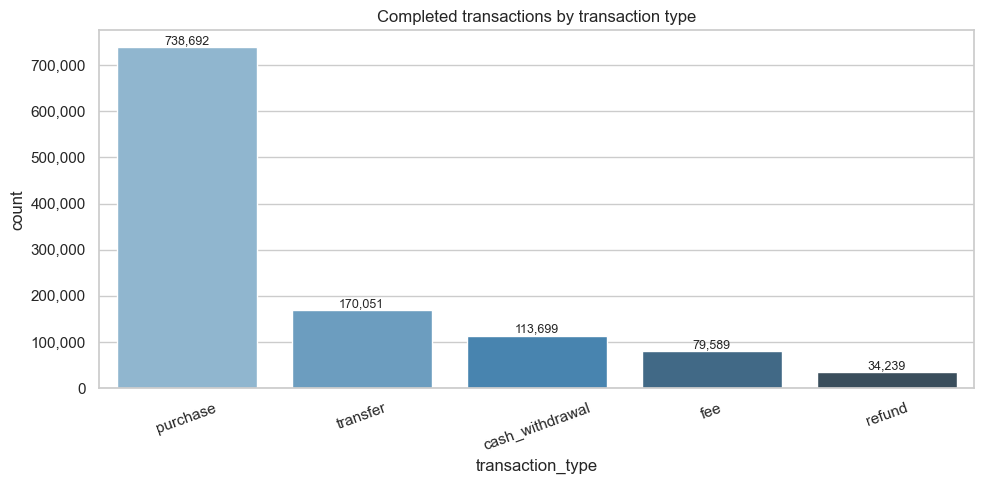

transaction_type
purchase           738692
transfer           170051
cash_withdrawal    113699
fee                 79589
refund              34239
Name: count, dtype: int64

In [10]:

# Transaction type distribution (absolute counts)
vc_tx_type = (
    df_tx["transaction_type"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=vc_tx_type.index, y=vc_tx_type.values, palette="Blues_d")
ax.set_title("Completed transactions by transaction type")
ax.set_xlabel("transaction_type")
ax.set_ylabel("count")
ax.tick_params(axis="x", rotation=20)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{int(x):,}"))

for i, v in enumerate(vc_tx_type.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

vc_tx_type


This chart above shows a strongly purchase-led transaction mix: purchases account for the vast majority of completed operations (about 739k, roughly two-thirds of total volume), while transfer (170k) and cash withdrawal (114k) form a secondary tier. Fee (80k) and refund (34k) are comparatively small, which is expected operationally, but still useful to monitor as quality signals. Overall, user behavior looks concentrated in value-generating transactions, with limited reversal activity.

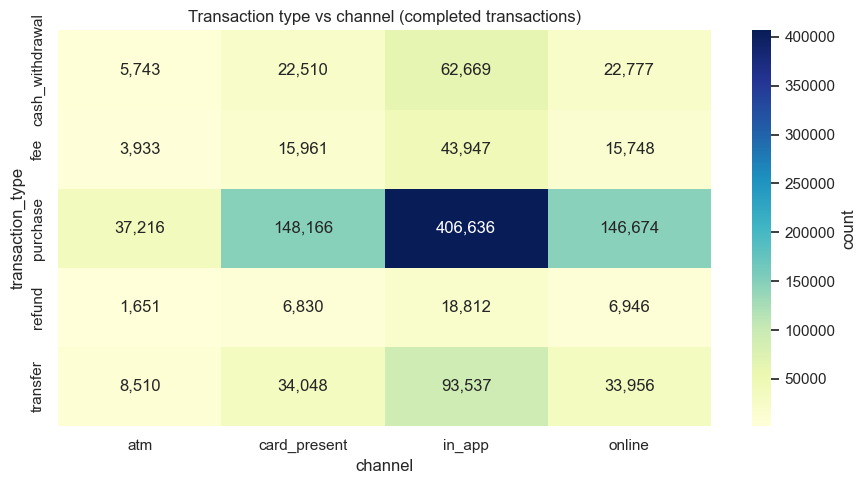

channel,atm,card_present,in_app,online
transaction_type,,,,
cash_withdrawal,5743,22510,62669,22777
fee,3933,15961,43947,15748
purchase,37216,148166,406636,146674
refund,1651,6830,18812,6946
transfer,8510,34048,93537,33956


In [11]:
# Heatmap: transaction_type x channel (absolute counts)
tx_type_channel = pd.crosstab(
    df_tx["transaction_type"],
    df_tx["channel"],
).sort_index()

plt.figure(figsize=(9, 5))
ax = sns.heatmap(
    tx_type_channel,
    annot=True,
    fmt=",d",
    cmap="YlGnBu",
    cbar_kws={"label": "count"},
)
ax.set_title("Transaction type vs channel (completed transactions)")
ax.set_xlabel("channel")
ax.set_ylabel("transaction_type")

plt.tight_layout()
plt.show()

tx_type_channel


This heatmap confirms that in_app is the dominant channel across every transaction type, especially for purchases (406,636), transfers (93,537), and cash withdrawals (62,669). Card-present and online are the second tier and are fairly balanced with each other, while ATM remains consistently the smallest channel.

**From a behavioral perspective, the channel mix is very stable by type (same ranking pattern), suggesting that segmentation differences may come more from volume/intensity than from radically different preferred channels.**

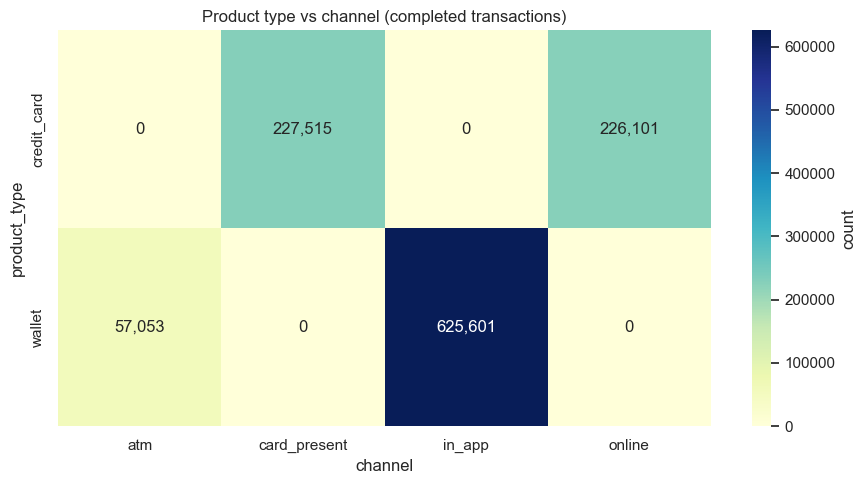

channel,atm,card_present,in_app,online
product_type,,,,
credit_card,0,227515,0,226101
wallet,57053,0,625601,0


In [13]:
# Heatmap: product_type x channel (absolute counts)
tx_type_channel = pd.crosstab(
    df_tx["product_type"],
    df_tx["channel"],
).sort_index()

plt.figure(figsize=(9, 5))
ax = sns.heatmap(
    tx_type_channel,
    annot=True,
    fmt=",d",
    cmap="YlGnBu",
    cbar_kws={"label": "count"},
)
ax.set_title("Product type vs channel (completed transactions)")
ax.set_xlabel("channel")
ax.set_ylabel("product_type")

plt.tight_layout()
plt.show()

tx_type_channel


<a id="part-2"></a>

## Part 2 — RFM metrics and Feature Engineering

**Goal:** compute customer-level **RFM metrics** from retained completed transactions, engineer supporting **behavioral features** for clustering, and prepare a clean feature matrix for segmentation analysis.

[↑ Back to summary](#summary)